<a href="https://colab.research.google.com/github/dikshit6381-maker/nassau-candy-profitability-analysis/blob/main/Nassau_Candy_Distributor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Imported Libraries
#--------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    palette="Set2")

# Suppress future warnings for clean output
#------------------------------------------
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [ ]:
# Loaded Dataset
#----------------

df = pd.read_csv("/content/Nassau Candy Distributor.csv")

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')

# numeric_cols = ['Sales', 'Cost', 'Units', 'Gross Profit']
# df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
display(df)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10189,10190,US-2024-143259-CHO-MIL-31000,2025-12-30,2030-06-26,Standard Class,143259,United States,New York City,New York,10009,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42
10190,10191,US-2024-115427-CHO-NUT-13000,2025-12-30,2030-06-26,Standard Class,115427,United States,Fairfield,California,94533,Chocolate,Pacific,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,6.98,2,4.98,2.00
10191,10192,US-2024-156720-CHO-SCR-58000,2025-12-30,2030-06-26,Standard Class,156720,United States,Loveland,Colorado,80538,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
10192,10193,US-2024-143259-CHO-TRI-54000,2025-12-30,2030-06-26,Standard Class,143259,United States,New York City,New York,10009,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,26.25,7,17.15,9.10


In [ ]:
# KPI Creation (Gross Margin (%), Profit per Unit, Cost to Sales Ratio)
#----------------------------------------------------------------------

df['Gross Margin (%)'] = (df['Gross Profit'] / df['Sales']) * 100
df['Profit per Unit'] = df['Gross Profit'] / df['Units']
df['Cost to Sales Ratio'] = df['Cost'] / df['Sales']
display(df)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Gross Margin (%),Profit per Unit,Cost to Sales Ratio
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,64.923077,2.11,0.350769
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,65.333333,2.45,0.346667
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,71.346705,2.49,0.286533
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,69.444444,2.50,0.305556
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,65.333333,2.45,0.346667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10189,10190,US-2024-143259-CHO-MIL-31000,2025-12-30,2030-06-26,Standard Class,143259,United States,New York City,New York,10009,...,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42,64.923077,2.11,0.350769
10190,10191,US-2024-115427-CHO-NUT-13000,2025-12-30,2030-06-26,Standard Class,115427,United States,Fairfield,California,94533,...,Pacific,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,6.98,2,4.98,2.00,71.346705,2.49,0.286533
10191,10192,US-2024-156720-CHO-SCR-58000,2025-12-30,2030-06-26,Standard Class,156720,United States,Loveland,Colorado,80538,...,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,69.444444,2.50,0.305556
10192,10193,US-2024-143259-CHO-TRI-54000,2025-12-30,2030-06-26,Standard Class,143259,United States,New York City,New York,10009,...,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,26.25,7,17.15,9.10,65.333333,2.45,0.346667


In [ ]:
# Handling Outliers
#------------------

def outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = np.where(
        data[col] < lower, lower,
        np.where(data[col] > upper, upper, data[col])
    )
    return data

outlier_columns = [
    'Sales', 'Cost', 'Units',
    'Gross Profit', 'Gross Margin (%)', 'Profit per Unit'
]

for col in outlier_columns:
    df = outliers_iqr(df, col)
display(df[outlier_columns])
display(df[outlier_columns].describe())

,Sales,Cost,Units,Gross Profit,Gross Margin (%),Profit per Unit
0,6.50,2.28,2.0,4.22,64.923077,2.265
1,7.50,2.60,2.0,4.90,65.333333,2.450
2,10.47,3.00,3.0,7.47,71.346705,2.490
3,10.80,3.30,3.0,7.50,69.444444,2.500
4,11.25,3.90,3.0,7.35,65.333333,2.450
...,...,...,...,...,...,...
10189,9.75,3.42,3.0,6.33,64.923077,2.265
10190,6.98,2.00,2.0,4.98,71.346705,2.490
10191,10.80,3.30,3.0,7.50,69.444444,2.500
10192,26.25,9.10,7.0,17.15,65.333333,2.450


,Sales,Cost,Units,Gross Profit,Gross Margin (%),Profit per Unit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,13.330992,4.374628,3.755690,8.906705,67.188350,2.416742
std,7.718469,2.519609,2.106231,5.261146,2.841243,0.091896
min,1.250000,0.600000,1.000000,0.250000,59.166667,2.265000
25%,7.200000,2.400000,2.000000,4.900000,65.333333,2.400000
50%,10.800000,3.600000,3.000000,7.470000,66.666667,2.450000
75%,18.000000,5.700000,5.000000,12.250000,69.444444,2.490000
max,34.200000,10.650000,9.500000,23.275000,75.611111,2.625000


In [ ]:
# KPI calculation after treating outliers
#----------------------------------------

df['Gross Margin (%)'] = (df['Gross Profit'] / df['Sales']) * 100
df['Profit per Unit'] = df['Gross Profit'] / df['Units']

total_sales = df['Sales'].sum()
total_profit = df['Gross Profit'].sum()

df['Revenue Contribution (%)'] = (df['Sales'] / total_sales) * 100
df['Profit Contribution (%)'] = (df['Gross Profit'] / total_profit) * 100
display(df)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Product Name,Sales,Units,Gross Profit,Cost,Gross Margin (%),Profit per Unit,Cost to Sales Ratio,Revenue Contribution (%),Profit Contribution (%)
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,Wonka Bar - Milk Chocolate,6.50,2.0,4.22,2.28,64.923077,2.11,0.350769,0.004783,0.004648
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Wonka Bar - Triple Dazzle Caramel,7.50,2.0,4.90,2.60,65.333333,2.45,0.346667,0.005519,0.005397
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Wonka Bar - Nutty Crunch Surprise,10.47,3.0,7.47,3.00,71.346705,2.49,0.286533,0.007704,0.008227
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,Wonka Bar -Scrumdiddlyumptious,10.80,3.0,7.50,3.30,69.444444,2.50,0.305556,0.007947,0.008260
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,Wonka Bar - Triple Dazzle Caramel,11.25,3.0,7.35,3.90,65.333333,2.45,0.346667,0.008278,0.008095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10189,10190,US-2024-143259-CHO-MIL-31000,2025-12-30,2030-06-26,Standard Class,143259,United States,New York City,New York,10009,...,Wonka Bar - Milk Chocolate,9.75,3.0,6.33,3.42,64.923077,2.11,0.350769,0.007175,0.006972
10190,10191,US-2024-115427-CHO-NUT-13000,2025-12-30,2030-06-26,Standard Class,115427,United States,Fairfield,California,94533,...,Wonka Bar - Nutty Crunch Surprise,6.98,2.0,4.98,2.00,71.346705,2.49,0.286533,0.005136,0.005485
10191,10192,US-2024-156720-CHO-SCR-58000,2025-12-30,2030-06-26,Standard Class,156720,United States,Loveland,Colorado,80538,...,Wonka Bar -Scrumdiddlyumptious,10.80,3.0,7.50,3.30,69.444444,2.50,0.305556,0.007947,0.008260
10192,10193,US-2024-143259-CHO-TRI-54000,2025-12-30,2030-06-26,Standard Class,143259,United States,New York City,New York,10009,...,Wonka Bar - Triple Dazzle Caramel,26.25,7.0,17.15,9.10,65.333333,2.45,0.346667,0.019316,0.018889


In [45]:
# Factory Mapping and Efficiency
#-------------------------------

factory_mapping = {
    'Wonka Bar': ["Lot's O' Nuts", "Wicked Choccy's"],
    'Laffy Taffy': ['Sugar Shack'],
    'SweeTARTS': ['Sugar Shack'],
    'Nerds': ['Sugar Shack'],
    'Fun Dip': ['Sugar Shack'],
    'Everlasting Gobstopper': ['Secret Factory'],
    'Hair Toffee': ['The Other Factory'],
    'Fizzy Lifting Drinks': ['Sugar Shack'],
    'Lickable Wallpaper': ['Secret Factory'],
    'Wonka Gum': ['Secret Factory'],
    'Kazookles': ['The Other Factory']
}

def assign_factory(product):
    for key, factory in factory_mapping.items():
        if key in product:
            return factory[0]
    return 'Unknown'

df['Factory'] = df['Product Name'].apply(assign_factory)

factory_efficiency = (
    df.groupby('Factory')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Units=('Units', 'sum'),
        Total_Cost=('Cost', 'sum'),
        Total_Profit=('Gross Profit', 'sum'),
        Avg_Gross_Margin=('Gross Margin (%)', 'mean'),
        Avg_Profit_per_Unit=('Profit per Unit', 'mean')
    )
    .reset_index()
)

factory_efficiency['Cost per Unit'] = factory_efficiency['Total_Cost'] / factory_efficiency['Total_Units']
factory_efficiency['Revenue per Unit'] = factory_efficiency['Total_Sales'] / factory_efficiency['Total_Units']

factory_efficiency = factory_efficiency.sort_values(by='Avg_Gross_Margin', ascending=False)
display(factory_efficiency)

,Factory,Total_Sales,Total_Units,Total_Cost,Total_Profit,Avg_Gross_Margin,Avg_Profit_per_Unit,Cost per Unit,Revenue per Unit
0,Lot's O' Nuts,130539.00,36920.0,42333.36,88081.525,67.468058,2.385814,1.146624,3.535726
1,Secret Factory,3853.90,870.5,1309.95,2439.950,57.873023,3.329801,1.504825,4.427226
2,Sugar Shack,220.98,107.0,99.75,121.230,53.225725,1.136364,0.932243,2.065234
3,The Other Factory,1282.25,388.0,851.90,152.250,10.495726,0.380000,2.195619,3.304768


In [46]:
# Executive KPI Calculations
#---------------------------
total_sales = df['Sales'].sum()
total_profit = df['Gross Profit'].sum()
avg_margin = (total_profit / total_sales) * 100

top_factory = (
    factory_efficiency
    .sort_values(by='Avg_Profit_per_Unit', ascending=False)
    .iloc[0]
)

top_factory_name = top_factory['Factory']
top_factory_ppu = top_factory['Avg_Profit_per_Unit']

product_profit = (
    df.groupby('Product Name')['Gross Profit']
    .sum()
    .reset_index()
    .sort_values(by='Gross Profit', ascending=False)
)

product_profit['Cumulative Profit %'] = (
    product_profit['Gross Profit'].cumsum() / total_profit
) * 100

top_20pct_count = int(0.2 * len(product_profit))

profit_top_20pct = (
    product_profit.head(top_20pct_count)['Gross Profit'].sum()
    / total_profit
) * 100


kpi_strip = pd.DataFrame({
    'KPI Name': [
        'Total Sales',
        'Total Profit',
        'Average Gross Margin (%)',
        'Top Factory (Profit per Unit)',
        'Profit from Top 20% Products (%)'
    ],
    'KPI Value': [
        round(total_sales, 2),
        round(total_profit, 2),
        round(avg_margin, 2),
        f"{top_factory_name} ({round(top_factory_ppu, 2)})",
        round(profit_top_20pct, 2)
    ]
})

dependency_flag = pd.DataFrame({
    'Indicator': ['Profit Dependency Level'],
    'Value': [
        'High' if profit_top_20pct > 80
        else 'Medium' if profit_top_20pct > 60
        else 'Low'
    ]
})
display(kpi_strip)
display(dependency_flag)

,KPI Name,KPI Value
0,Total Sales,135896.13
1,Total Profit,90794.96
2,Average Gross Margin (%),66.81
3,Top Factory (Profit per Unit),Secret Factory (3.33)
4,Profit from Top 20% Products (%),60.52


,Indicator,Value
0,Profit Dependency Level,Medium


In [ ]:
# Product Performance
#--------------------

product_perf = (
    df.groupby(['Division', 'Product Name'])
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Gross Profit', 'sum'),
        Avg_Margin=('Gross Margin (%)', 'mean'),
        Avg_Profit_per_Unit=('Profit per Unit', 'mean')
    )
    .reset_index()
)
display(product_perf)

,Division,Product Name,Total_Sales,Total_Profit,Avg_Margin,Avg_Profit_per_Unit
0,Chocolate,Wonka Bar - Fudge Mallows,24647.40,16446.325,66.690350,2.400853
1,Chocolate,Wonka Bar - Milk Chocolate,26663.55,17341.475,64.965052,2.115270
2,Chocolate,Wonka Bar - Nutty Crunch Surprise,23419.95,16684.600,71.306702,2.489514
3,Chocolate,Wonka Bar - Triple Dazzle Caramel,28196.10,18452.175,65.377916,2.450000
4,Chocolate,Wonka Bar -Scrumdiddlyumptious,27612.00,19156.950,69.418874,2.499079
5,Other,Kazookles,1205.75,92.750,7.692308,0.250000
6,Other,Lickable Wallpaper,3158.00,2059.425,64.944164,6.665931
7,Other,Wonka Gum,597.50,310.700,52.000000,0.654276
8,Sugar,Everlasting Gobstopper,98.40,69.825,71.231481,5.818750
9,Sugar,Fizzy Lifting Drinks,78.75,47.250,60.000000,2.250000


In [ ]:
# Division Performance
#---------------------

division_perf = (
    df.groupby('Division')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Gross Profit', 'sum'),
        Avg_Margin=('Gross Margin (%)', 'mean')
    )
    .reset_index()
)
display(division_perf)

,Division,Total_Sales,Total_Profit,Avg_Margin
0,Chocolate,130539.00,88081.525,67.468058
1,Other,4961.25,2462.875,42.203913
2,Sugar,395.88,250.555,57.031362


In [ ]:
# Regional Performance
#---------------------

regional_perf = (
    df.groupby('Region')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Gross Profit', 'sum'),
        Avg_Margin=('Gross Margin (%)', 'mean')
    )
    .reset_index()
    .sort_values(by='Total_Sales', ascending=False)
)
display(regional_perf)

,Region,Total_Sales,Total_Profit,Avg_Margin
3,Pacific,44102.10,29495.355,66.756179
0,Atlantic,39253.17,26116.785,66.373697
2,Interior,30922.13,20785.550,66.989144
1,Gulf,21618.73,14397.265,66.512755


In [ ]:
# Time Trend Analysis
#--------------------

df['Year'] = df['Order Date'].dt.year

yearly_trend = (
    df.groupby('Year')
    .agg(
        Sales=('Sales', 'sum'),
        Profit=('Gross Profit', 'sum'),
        Avg_Margin=('Gross Margin (%)', 'mean')
    )
    .reset_index()
)
display(yearly_trend)

,Year,Sales,Profit,Avg_Margin
0,2024,55621.70,37093.085,66.531356
1,2025,80274.43,53701.870,66.747452


In [ ]:
# Risk Identification
#--------------------

margin_volatility = (
    df.groupby(['Product Name', 'Year'])['Gross Margin (%)']
    .mean()
    .groupby('Product Name')
    .std()
    .reset_index(name='Margin Volatility')
    .sort_values(by='Margin Volatility', ascending=False)
)
display(margin_volatility)

,Product Name,Margin Volatility
6,Lickable Wallpaper,1.529335
13,Wonka Bar -Scrumdiddlyumptious,0.010273
12,Wonka Bar - Triple Dazzle Caramel,0.010176
11,Wonka Bar - Nutty Crunch Surprise,0.008177
10,Wonka Bar - Milk Chocolate,0.007098
9,Wonka Bar - Fudge Mallows,0.004492
1,Fizzy Lifting Drinks,0.000000
4,Kazookles,0.000000
5,Laffy Taffy,0.000000
8,SweeTARTS,0.000000


In [ ]:
# Product Portfolio
#------------------

sales_threshold = product_perf['Total_Sales'].median()
margin_threshold = product_perf['Avg_Margin'].median()

def portfolio_category(row):
    if row['Total_Sales'] >= sales_threshold and row['Avg_Margin'] >= margin_threshold:
        return 'Star Product'
    elif row['Total_Sales'] >= sales_threshold:
        return 'Volume Driver (Low Margin)'
    elif row['Avg_Margin'] >= margin_threshold:
        return 'Niche High Margin'
    else:
        return 'Underperformer'

product_perf['Portfolio Category'] = product_perf.apply(portfolio_category, axis=1)
display(product_perf)

,Division,Product Name,Total_Sales,Total_Profit,Avg_Margin,Avg_Profit_per_Unit,Portfolio Category,Margin Band
0,Chocolate,Wonka Bar - Fudge Mallows,24647.40,16446.325,66.690350,2.400853,Star Product,High Margin
1,Chocolate,Wonka Bar - Milk Chocolate,26663.55,17341.475,64.965052,2.115270,Star Product,High Margin
2,Chocolate,Wonka Bar - Nutty Crunch Surprise,23419.95,16684.600,71.306702,2.489514,Star Product,High Margin
3,Chocolate,Wonka Bar - Triple Dazzle Caramel,28196.10,18452.175,65.377916,2.450000,Star Product,High Margin
4,Chocolate,Wonka Bar -Scrumdiddlyumptious,27612.00,19156.950,69.418874,2.499079,Star Product,High Margin
5,Other,Kazookles,1205.75,92.750,7.692308,0.250000,Volume Driver (Low Margin),Low Margin
6,Other,Lickable Wallpaper,3158.00,2059.425,64.944164,6.665931,Star Product,High Margin
7,Other,Wonka Gum,597.50,310.700,52.000000,0.654276,Volume Driver (Low Margin),High Margin
8,Sugar,Everlasting Gobstopper,98.40,69.825,71.231481,5.818750,Niche High Margin,High Margin
9,Sugar,Fizzy Lifting Drinks,78.75,47.250,60.000000,2.250000,Underperformer,High Margin


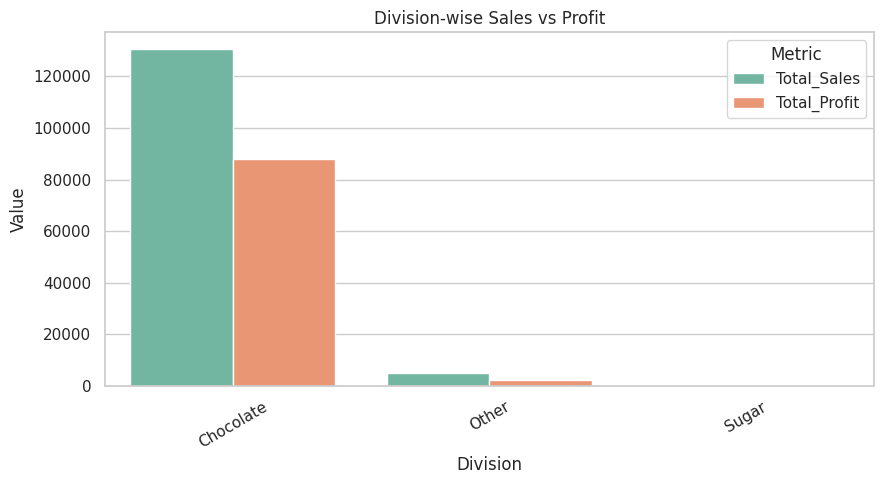

In [ ]:
# Sales vs Profit
#----------------

division_melted = division_perf.melt(
    id_vars='Division',
    value_vars=['Total_Sales', 'Total_Profit'],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(9,5))
sns.barplot(data=division_melted, x='Division', y='Value', hue='Metric')
plt.title("Division-wise Sales vs Profit")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


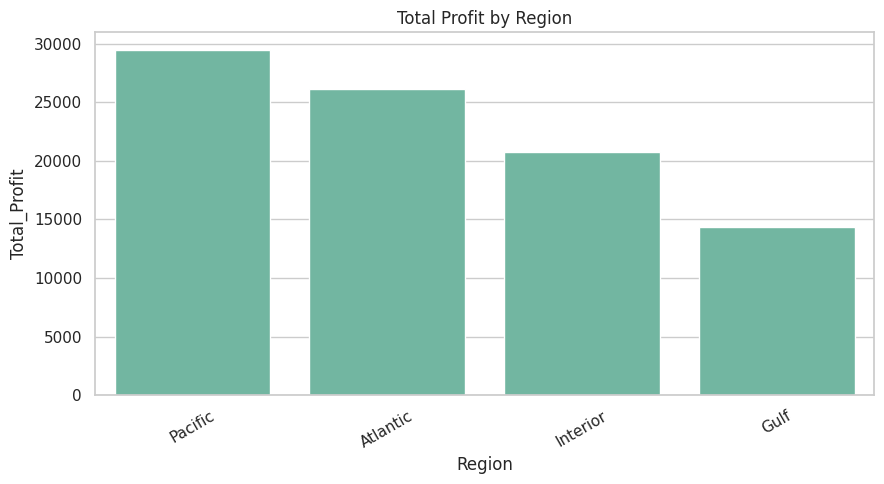

In [ ]:
# Regional Profit
#----------------

plt.figure(figsize=(9,5))
sns.barplot(data=regional_perf, x='Region', y='Total_Profit')
plt.title("Total Profit by Region")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


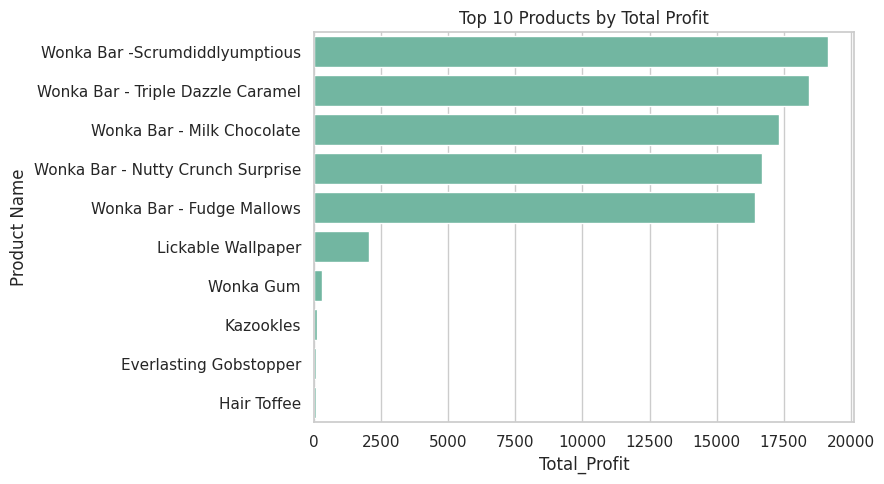

In [ ]:
# Top 10 products by Profit
#--------------------------

top_products = product_perf.sort_values(
    by='Total_Profit', ascending=False
).head(10)

plt.figure(figsize=(9,5))
sns.barplot(data=top_products, y='Product Name', x='Total_Profit')
plt.title("Top 10 Products by Total Profit")
plt.tight_layout()
plt.show()


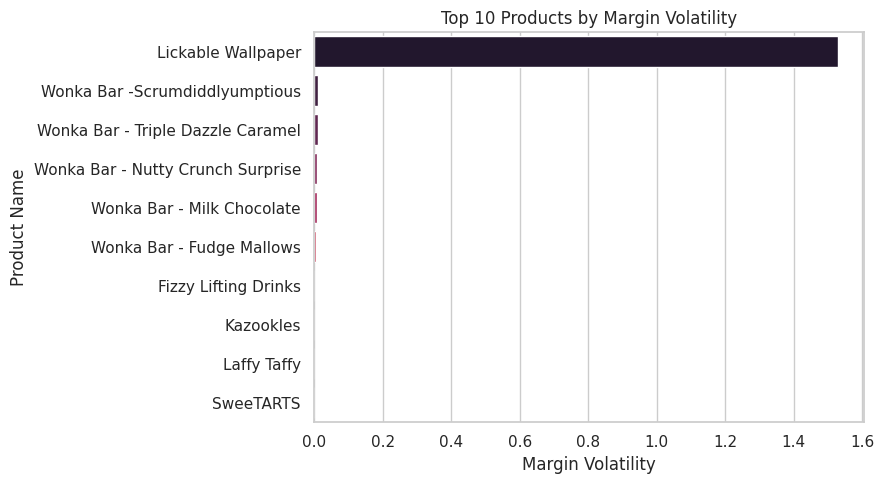

In [ ]:
# High-Risk Products
#-------------------

top_volatility = margin_volatility.head(10)

plt.figure(figsize=(9,5))
sns.barplot(
    data=top_volatility,
    y='Product Name',
    x='Margin Volatility',
    palette='rocket'
)
plt.title("Top 10 Products by Margin Volatility")
plt.tight_layout()
plt.show()


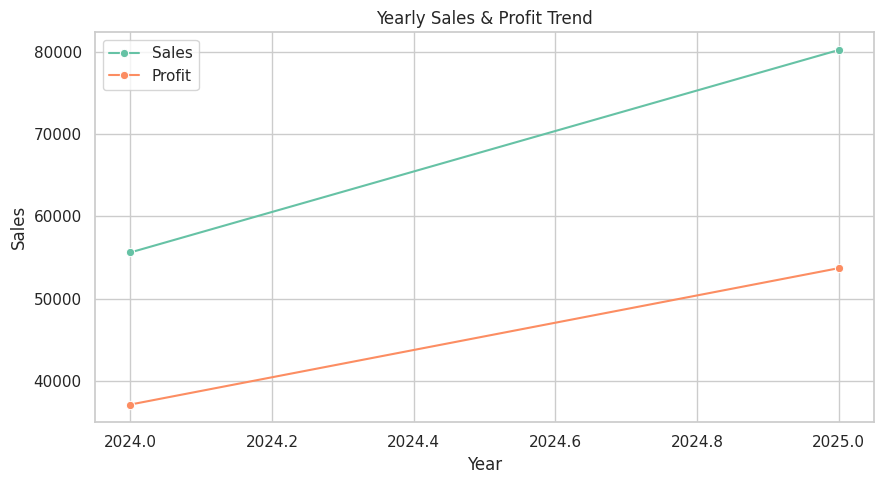

In [ ]:
# Yearly Sales & Profit Trend
#----------------------------

plt.figure(figsize=(9,5))
sns.lineplot(data=yearly_trend, x='Year', y='Sales', marker='o', label='Sales')
sns.lineplot(data=yearly_trend, x='Year', y='Profit', marker='o', label='Profit')
plt.title("Yearly Sales & Profit Trend")
plt.tight_layout()
plt.show()


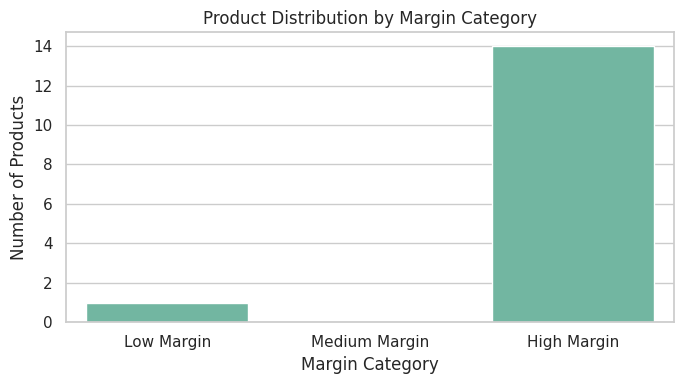

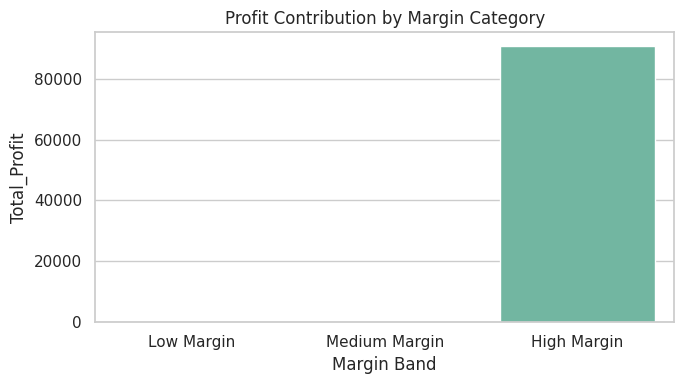

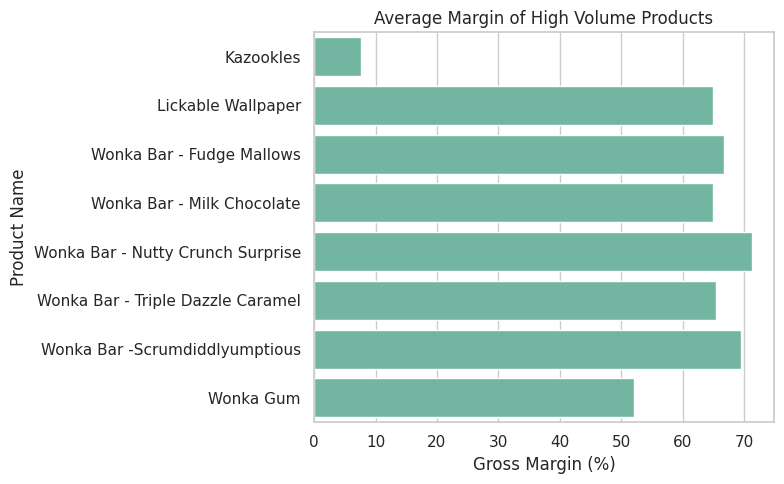

In [ ]:
# Product Portfolio
#------------------

product_perf['Margin Band'] = pd.cut(
    product_perf['Avg_Margin'],
    bins=[-np.inf, 10, 30, np.inf],
    labels=['Low Margin', 'Medium Margin', 'High Margin']
)
plt.figure(figsize=(7,4))
sns.countplot(
    data=product_perf,
    x='Margin Band',
    order=['Low Margin','Medium Margin','High Margin']
)
plt.title("Product Distribution by Margin Category")
plt.xlabel("Margin Category")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

margin_profit = (                         # Profit comes from healthy or risky margins
    product_perf.groupby('Margin Band')['Total_Profit']
    .sum()
    .reset_index()
)

plt.figure(figsize=(7,4))
sns.barplot(
    data=margin_profit,
    x='Margin Band',
    y='Total_Profit',
    order=['Low Margin','Medium Margin','High Margin']
)
plt.title("Profit Contribution by Margin Category")
plt.tight_layout()
plt.show()

top_volume = product_perf[product_perf['Total_Sales'] >= sales_threshold]

top_volume_margin = (                        # High volume products with high margin
    df[df['Product Name'].isin(top_volume['Product Name'])]
    .groupby('Product Name')['Gross Margin (%)']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=top_volume_margin,
    y='Product Name',
    x='Gross Margin (%)'
)
plt.title("Average Margin of High Volume Products")
plt.tight_layout()
plt.show()

In [ ]:
print("Dataset Summary After Outlier Treatment:")
display(df[outlier_columns].describe())

print("Product Portfolio Distribution:")
display(product_perf['Portfolio Category'].value_counts())
display("Products:")
display((product_perf[product_perf['Portfolio Category'] == 'Star Product']),
(product_perf[product_perf['Portfolio Category'] == 'Underperformer']),
(product_perf[product_perf['Portfolio Category'] == 'Volume Driver (Low Margin)']),
(product_perf[product_perf['Portfolio Category'] == 'Niche High Margin']))


Dataset Summary After Outlier Treatment:


,Sales,Cost,Units,Gross Profit,Gross Margin (%),Profit per Unit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,13.330992,4.374628,3.755690,8.906705,66.658821,2.382188
std,7.718469,2.519609,2.106231,5.261146,6.542513,0.585404
min,1.250000,0.600000,1.000000,0.250000,7.692308,0.250000
25%,7.200000,2.400000,2.000000,4.900000,65.333333,2.400000
50%,10.800000,3.600000,3.000000,7.470000,66.666667,2.450000
75%,18.000000,5.700000,5.000000,12.250000,69.444444,2.490000
max,34.200000,10.650000,9.500000,23.275000,77.777778,10.000000


Product Portfolio Distribution:


,count
Portfolio Category,
Star Product,6
Underperformer,5
Volume Driver (Low Margin),2
Niche High Margin,2


'Products:'

,Division,Product Name,Total_Sales,Total_Profit,Avg_Margin,Avg_Profit_per_Unit,Portfolio Category,Margin Band
0,Chocolate,Wonka Bar - Fudge Mallows,24647.40,16446.325,66.690350,2.400853,Star Product,High Margin
1,Chocolate,Wonka Bar - Milk Chocolate,26663.55,17341.475,64.965052,2.115270,Star Product,High Margin
2,Chocolate,Wonka Bar - Nutty Crunch Surprise,23419.95,16684.600,71.306702,2.489514,Star Product,High Margin
3,Chocolate,Wonka Bar - Triple Dazzle Caramel,28196.10,18452.175,65.377916,2.450000,Star Product,High Margin
4,Chocolate,Wonka Bar -Scrumdiddlyumptious,27612.00,19156.950,69.418874,2.499079,Star Product,High Margin
6,Other,Lickable Wallpaper,3158.00,2059.425,64.944164,6.665931,Star Product,High Margin


,Division,Product Name,Total_Sales,Total_Profit,Avg_Margin,Avg_Profit_per_Unit,Portfolio Category,Margin Band
9,Sugar,Fizzy Lifting Drinks,78.75,47.25,60.000000,2.25,Underperformer,High Margin
10,Sugar,Fun Dip,12.00,4.80,40.000000,0.60,Underperformer,High Margin
12,Sugar,Laffy Taffy,53.73,33.48,62.311558,1.24,Underperformer,High Margin
13,Sugar,Nerds,15.00,7.00,46.666667,0.70,Underperformer,High Margin
14,Sugar,SweeTARTS,61.50,28.70,46.666667,0.70,Underperformer,High Margin


,Division,Product Name,Total_Sales,Total_Profit,Avg_Margin,Avg_Profit_per_Unit,Portfolio Category,Margin Band
5,Other,Kazookles,1205.75,92.75,7.692308,0.250000,Volume Driver (Low Margin),Low Margin
7,Other,Wonka Gum,597.50,310.70,52.000000,0.654276,Volume Driver (Low Margin),High Margin


,Division,Product Name,Total_Sales,Total_Profit,Avg_Margin,Avg_Profit_per_Unit,Portfolio Category,Margin Band
8,Sugar,Everlasting Gobstopper,98.4,69.825,71.231481,5.81875,Niche High Margin,High Margin
11,Sugar,Hair Toffee,76.5,59.500,77.777778,3.50000,Niche High Margin,High Margin


In [47]:
# -----------------------------------
# Export to CSV for Power BI
# -----------------------------------
df.to_csv("Cleaned_Sales_Data.csv", index=False)
factory_efficiency.to_csv("Factory_Efficiency.csv", index=False)
division_perf.to_csv("Division_Performance.csv", index=False)
product_perf.to_csv("Product_Performance.csv", index=False)
regional_perf.to_csv("Regional_Performance.csv", index=False)
margin_volatility.to_csv("Margin_Volatility.csv", index=False)
yearly_trend.to_csv("Yearly_Trend.csv", index=False)
kpi_strip.to_csv("Executive_KPI_Strip.csv", index=False)
dependency_flag.to_csv("Profit_Dependency_Indicator.csv", index=False)